# PREVISIONE POPOLARITÀ CANZONI

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione e Contesto

### 1.1 Obiettivi del progetto

- **Obiettivo 1** — Predire la popolarità di un brano (regressione sullo score 0–100 e classificazione in classi Low/Medium/High).
- **Obiettivo 2** — Raccomandare brani simili dato un brano in input (content-based recommendation).

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Dataset utilizzati
Dataset principale: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (su kaggle) — ~114k tracce, 125 generi, 20 colonne, contiene un insieme di brani Spotify, appartenenti a diversi generi musicali, corredati delle rispettive caratteristiche audio.

In [35]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

df.info(verbose=False, memory_usage="deep");
df.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


### 1.3 Descrizione delle variabili
#### Metadati:
- `artists`
- `album_name`
- `track_name`
- `track_genre`
- `duration_ms`
- `explicit`
#### Feature audio (0–1 se non indicato altrimenti):
- `danceability`
- `energy`
- `key (0–11)`
- `loudness (dB)`
- `mode`
- `speechiness`
- `acousticness`
- `instrumentalness`
- `liveness`
- `valence`
- `tempo (BPM)`
- `time_signature (3–7)`
#### Target (da predire):
- `popularity (0-100)`

### 1.4 Pulizia iniziale dei dati
Prima di procedere con l’analisi dei dati, si effettua una prima fase di scrematura.

#### Rimozione colonne non informative:

`track_id`: identificatore univoco di un brano, rimosso poichè non utile al modello utile al modello.

In [36]:
df.drop(columns=["track_id"], inplace=True)

#### Valori nulli:
Rimozione di eventuali righe con valori nulli.

In [37]:
df.isnull().sum()
df = df.dropna()

Rimozione dei brani con `popularity` = 0.

In [38]:
df.info(verbose=False, memory_usage="deep")
df = df[df['popularity'] != 0]
print('----------------------------------------------------')
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), str(4)
memory usage: 41.9 MB
----------------------------------------------------
<class 'pandas.DataFrame'>
Index: 97980 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), str(4)
memory usage: 36.0 MB


Una frazione consistente del dataset ha `popularity` = 0.

Questo insieme è formato da:
- brani senza ascolti
- brani recenti
- artefatti

Il target per queste righe è di fatto mancante. Se non rimosse rischiano di distorce la regressione.

#### Duplicati
Il dataset contiene molte righe con stesso `track_name` + `artists` (stesso brano in più album). 
Questo è un problema per due motivi:

- inquinano il test set: lo stesso brano in train e test → leakage classico;
- distorcono l'EDA: generi con molte compilation (acoustic, christmas) risultano sovrarappresentati.

Aggregaione dei brani con stesso nome e artisti, mantenendo solo la versione con popularity massima.

In [39]:
df.info(verbose=False, memory_usage="deep")
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])
print('----------------------------------------------------')
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 97980 entries, 0 to 113999
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), str(4)
memory usage: 36.0 MB
----------------------------------------------------
<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 19 entries, artists to track_genre
dtypes: bool(1), float64(9), int64(5), str(4)
memory usage: 28.6 MB


### 1.5 Conversioni e derivazioni
Conversione dei millisecondi in secondi.

In [40]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

Creazione della colonna `num_artists` (numero di artisti per ogni brano).

In [41]:
df['num_artists'] = df['artists'].astype(str).str.split(';').str.len()
df.head(1)

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s,num_artists
20001,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,dance,156.943,2


Con questa prima scrematura, la dimensione del dataset è stata ridotta ulteriormente.

In [42]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 20 entries, artists to num_artists
dtypes: bool(1), float64(10), int64(5), str(4)
memory usage: 29.2 MB


## 2. Analisi dei dati

### 2.1 Statistiche descrittive generali

In [43]:
print('tracks: \t' + str(len(df)))
print('artists:\t' + str(df['artists'].nunique()))
print('albums: \t' + str(df.groupby(['album_name', 'artists'], observed=True).ngroups))
print('genres: \t' + str(df['track_genre'].nunique()))
df.describe()

tracks: 	76585
artists:	29826
albums: 	53196
genres: 	114


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s,num_artists
count,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000
mean,37.439303,0.561695,0.640234,5.287263,-8.496698,0.633349,0.089653,0.322805,0.183126,0.221368,0.465632,122.416330,3.900268,231.499167,1.368036
std,17.837212,0.176131,0.255269,3.558216,5.187510,0.481893,0.118414,0.335335,0.330334,0.200116,0.262399,30.075551,0.450232,116.630574,0.881734
min,1.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.266000,1.000000
25%,23.000000,0.450000,0.464000,2.000000,-10.327000,0.000000,0.036000,0.015000,0.000000,0.098700,0.246000,99.915000,4.000000,173.973000,1.000000
50%,37.000000,0.575000,0.682000,5.000000,-7.232000,1.000000,0.049200,0.184000,0.000085,0.133000,0.451000,122.369000,4.000000,215.689000,1.000000
75%,50.000000,0.691000,0.859000,8.000000,-5.130000,1.000000,0.087600,0.614000,0.144000,0.285000,0.677000,140.655000,4.000000,267.847000,1.000000
max,100.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,5237.295000,38.000000


Il dataset contiene quindi informazioni relative a 76585 brani, 29826 artisti, 53199 album e 114 generi.

### 2.2 Distribuzione delle feature

Di seguito vengono visualizzati alcuni istogrammi e statistiche per analizzare la distribuzione dei dati.

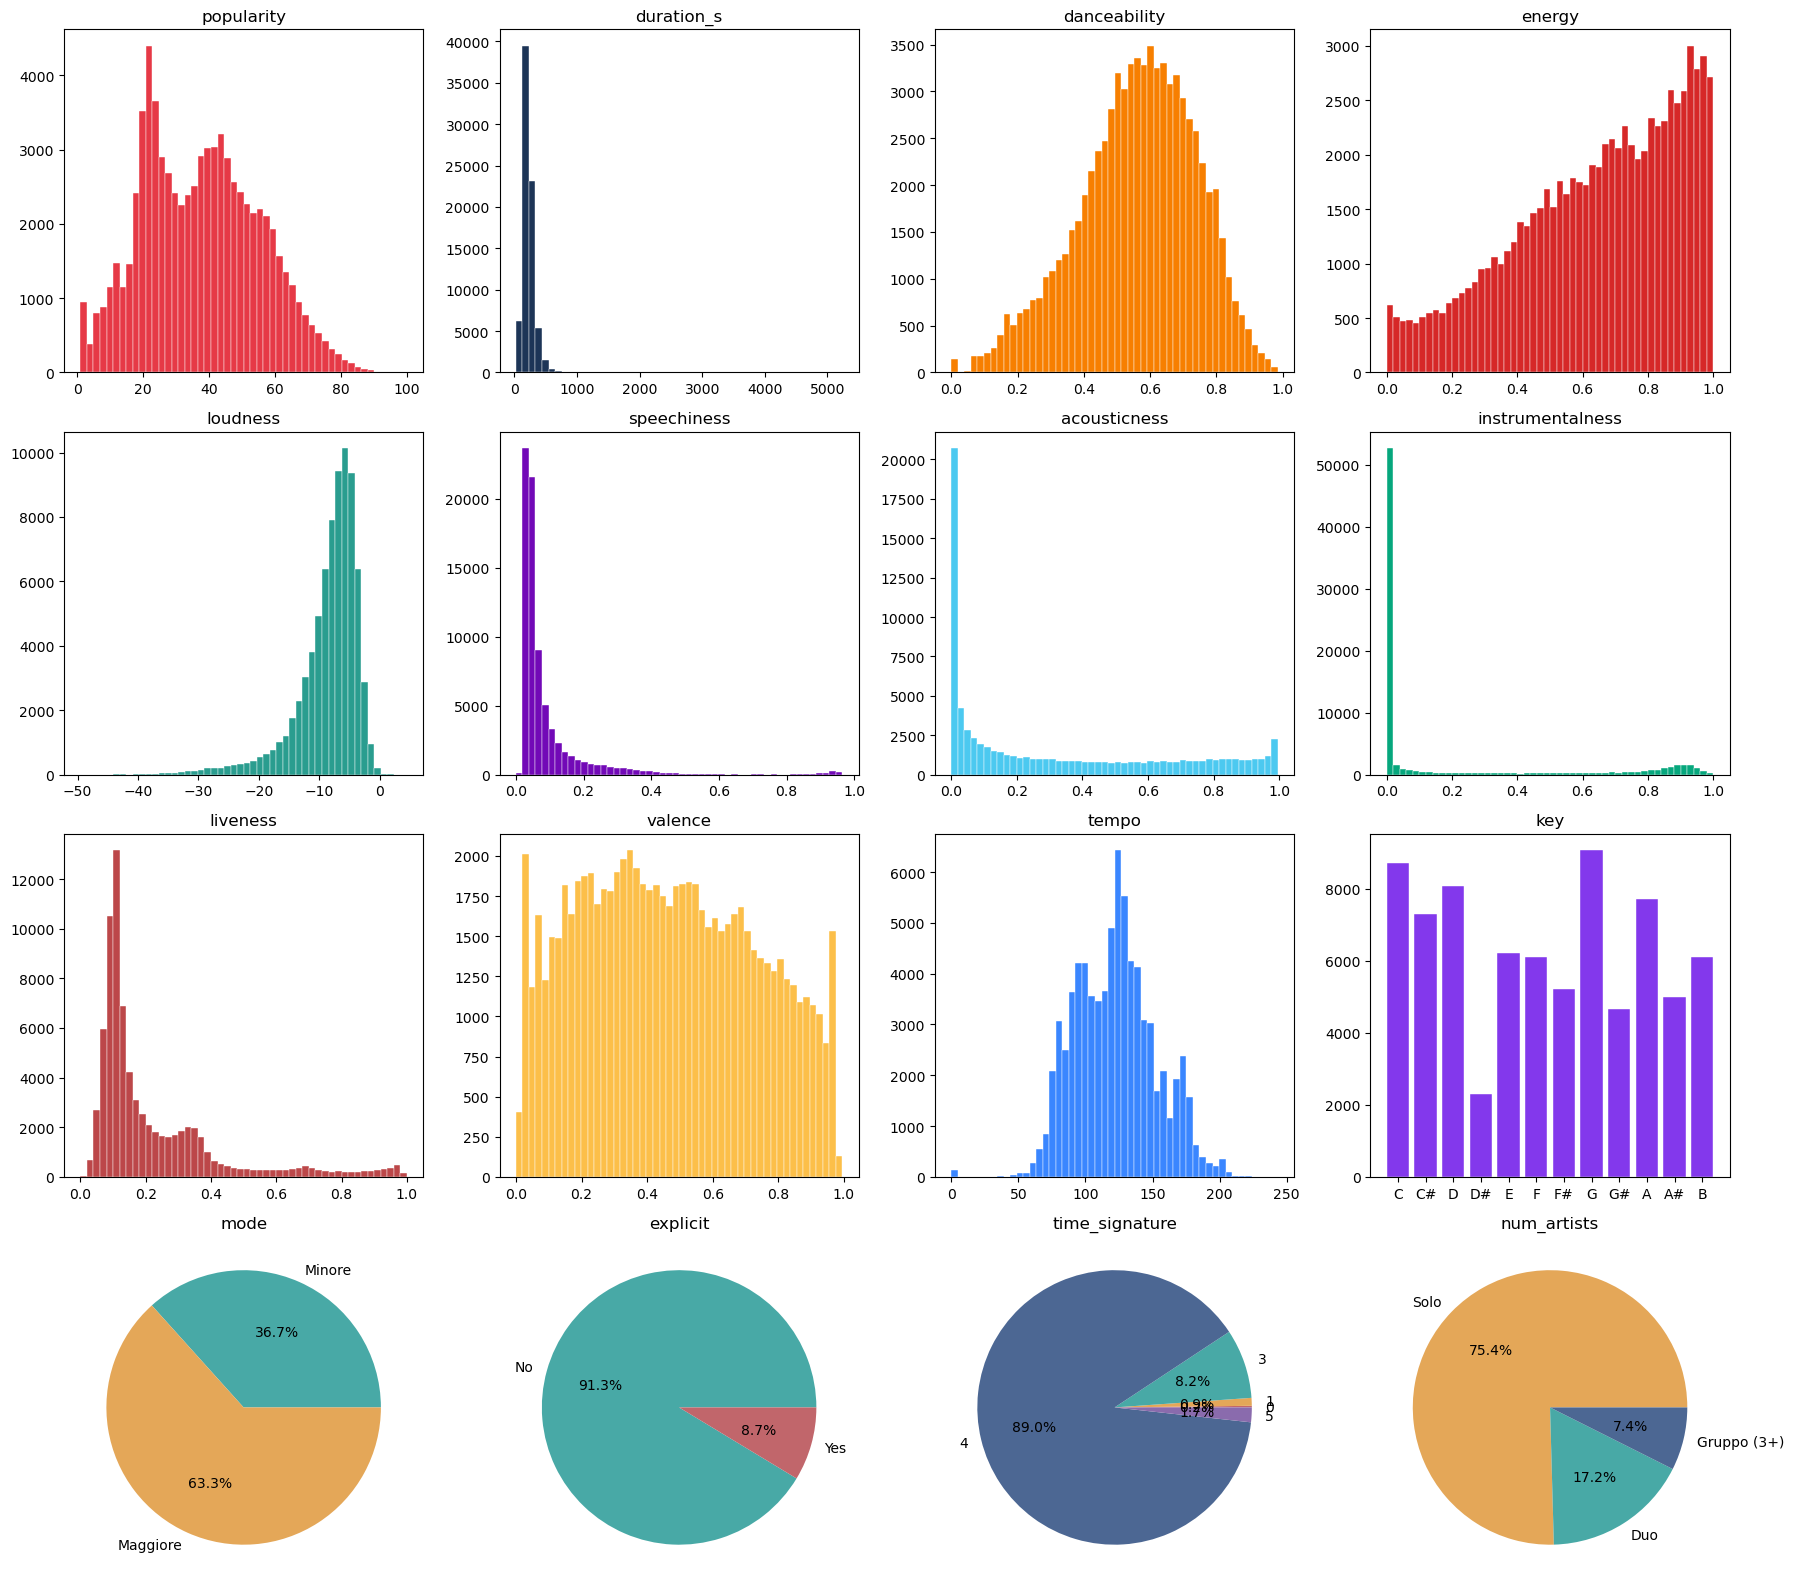

In [44]:
import numpy as np

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# Palette tematica: un colore acceso per ogni feature, uniforme dentro ciascun grafico
feature_colors = {
    'popularity': '#E63946',        # rosso corallo — il target
    'duration_s': '#1D3557',        # blu navy
    'danceability': '#F77F00',      # arancio vivo
    'energy': '#D62828',            # rosso intenso
    'loudness': '#2A9D8F',          # verde-azzurro
    'speechiness': '#7209B7',       # viola intenso
    'acousticness': '#4CC9F0',      # azzurro cielo
    'instrumentalness': '#06A77D',  # verde smeraldo
    'liveness': '#BC4749',          # rosso mattone
    'valence': '#FCBF49',           # giallo oro
    'tempo': '#3A86FF',             # blu elettrico
    'key': '#8338EC',               # viola elettrico
}

# Feature continue con istogrammi
continuous = [
    ('popularity', False),
    ('duration_s', True),
    ('danceability', False),
    ('energy', False),
    ('loudness', False),
    ('speechiness', False),
    ('acousticness', False),
    ('instrumentalness', False),
    ('liveness', False),
    ('valence', False),
    ('tempo', True),
]

for i, (feat, truncate) in enumerate(continuous):
    data = df[feat]
    color = feature_colors[feat]
    axes[i].hist(data, bins=50, color=color, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat)

offset = len(continuous)  # 11

# key — tutto dello stesso colore
key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
key_counts = df['key'].value_counts().sort_index()
axes[offset].bar(
    [key_labels[int(k)] for k in key_counts.index],
    key_counts.values,
    color=feature_colors['key'],
    edgecolor='white', linewidth=0.3
)
axes[offset].set_title('key')

# mode — torta
mode_counts = df['mode'].value_counts().sort_index()
axes[offset+1].pie(
    mode_counts.values,
    labels=['Minore', 'Maggiore'],
    colors=['#48A9A6', '#E4A758'],  # verde-acqua, ocra
    autopct='%1.1f%%'
)
axes[offset+1].set_title('mode')

# explicit — torta
exp_counts = df['explicit'].value_counts()
axes[offset+2].pie(
    [exp_counts[False], exp_counts[True]],
    labels=['No', 'Yes'],
    colors=['#48A9A6', '#C1666B'],  # verde-acqua, rosso tenue
    autopct='%1.1f%%'
)
axes[offset+2].set_title('explicit')

# time_signature — torta
ts_counts = df['time_signature'].value_counts().sort_index()
axes[offset+3].pie(
    ts_counts.values,
    labels=[str(int(t)) for t in ts_counts.index],
    colors=['#C1666B', '#E4A758', '#48A9A6', '#4C6793', '#8A6BAD'],
    autopct='%1.1f%%'
)
axes[offset+3].set_title('time_signature')

# num_artists — torta
na = df['num_artists']
na_grouped = na.where(na <= 2, 3).value_counts().sort_index()
axes[offset+4].pie(
    na_grouped.values,
    labels=['Solo', 'Duo', 'Gruppo (3+)'],
    colors=['#E4A758', '#48A9A6', '#4C6793'],  # ocra → verde-acqua → blu
    autopct='%1.1f%%'
)
axes[offset+4].set_title('num_artists')

plt.tight_layout()
plt.show()

Osservazioni principali sulle distribuzioni:

- `popularity`, `duration_s` e `speechiness` mostrano forte asimmetria con coda a destra.
- `instrumentalness` è fortemente **bimodale**: la maggior parte dei brani ha valore ≈ 0 (cantati), una minoranza si concentra a valori alti (strumentali).
- `loudness` è asimmetrica negativamente, con la maggior parte dei brani compresa tra −10 e −5 dB.
- `key` e `time_signature` sono dominate rispettivamente da `C`/`G` e da `4/4`, distribuzioni attese per la musica commerciale.
- `mode` è sbilanciato verso il maggiore (~65%), anche questo atteso.

### 2.3 Correlazione tra le feature

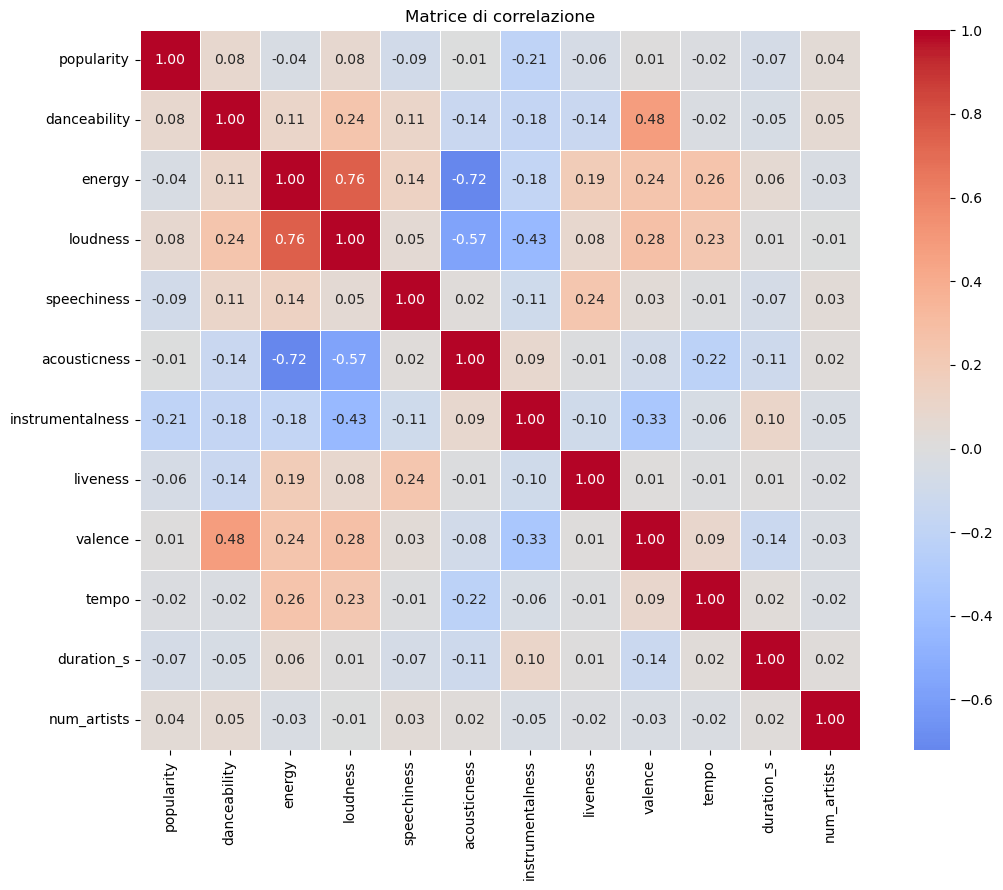

In [45]:
import seaborn as sns

numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_s', 'num_artists']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [46]:
corr_popularity = corr['popularity'].drop('popularity').sort_values(ascending=False)
print("Correlazione con popularity:")
print(corr_popularity.round(3))

Correlazione con popularity:
danceability        0.083
loudness            0.078
num_artists         0.043
valence             0.006
acousticness       -0.007
tempo              -0.019
energy             -0.037
liveness           -0.058
duration_s         -0.067
speechiness        -0.091
instrumentalness   -0.207
Name: popularity, dtype: float64


Dalla matrice di correlazione emergono alcune osservazioni rilevanti:

- Nessuna feature audio presenta una correlazione forte con `popularity` (tutti i valori sono sotto 0.3), confermando che la popolarità di un brano non dipende linearmente da una singola caratteristica audio.
- Le correlazioni più alte con `popularity` sono quelle di `loudness` e `danceability` (positive) e `acousticness` e `instrumentalness` (negative): i brani più popolari tendono ad essere più energici e meno acustici.
- Si nota una forte correlazione tra `energy` e `loudness` (attesa, poiché brani più energici sono generalmente più forti) e tra `energy` e `acousticness` (negativa, brani acustici sono tipicamente meno energici).

### 2.4 Relazione tra feature audio e popularity

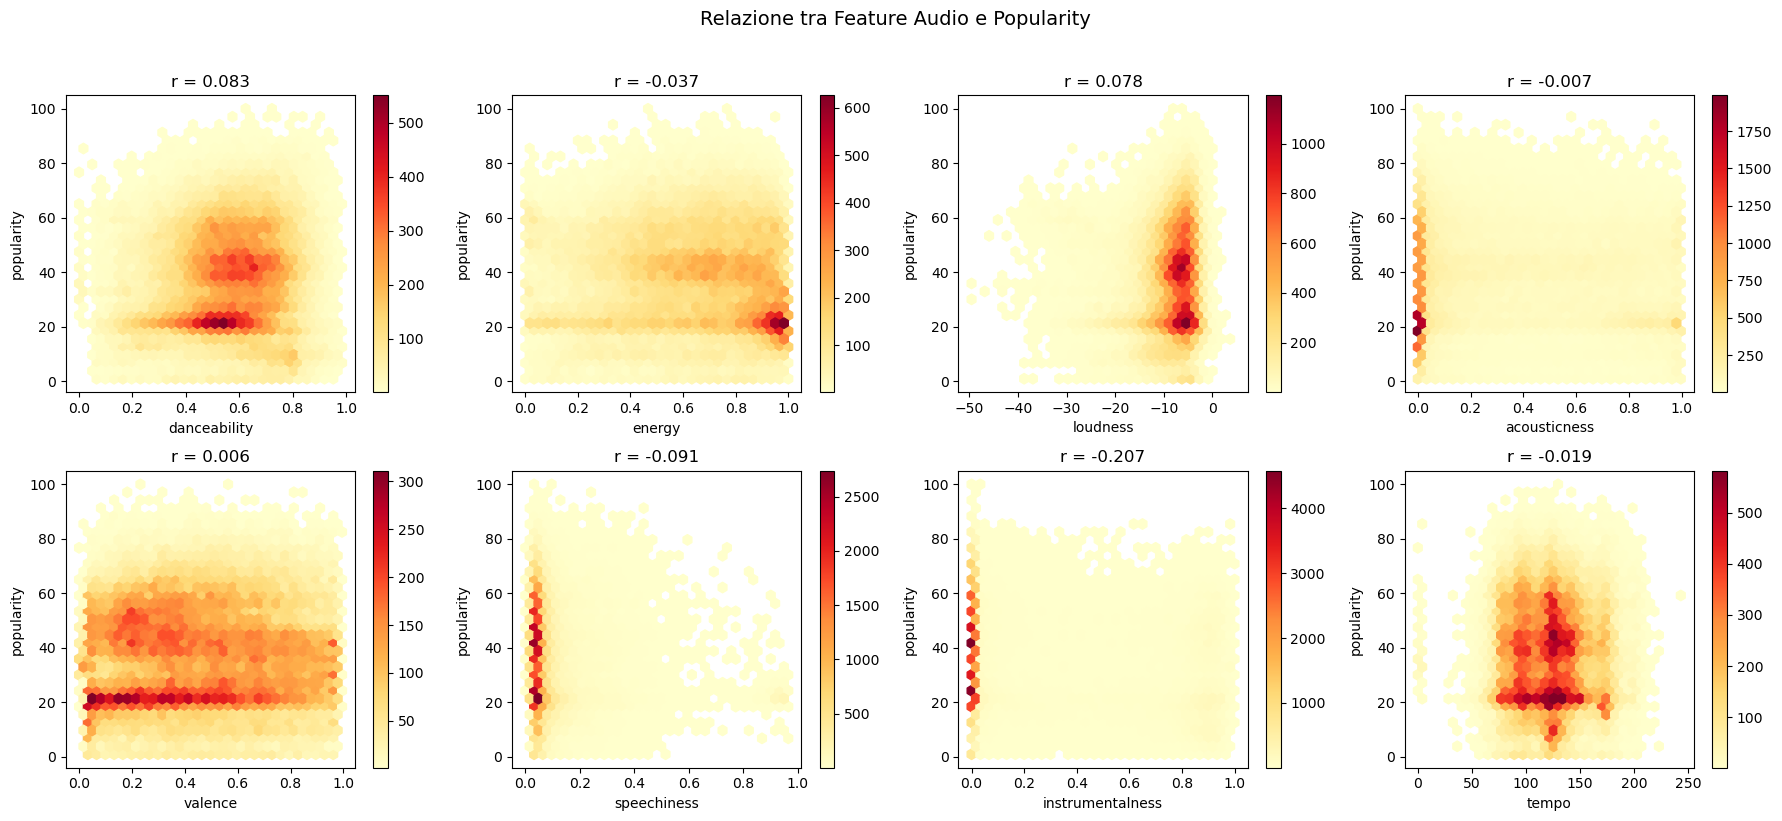

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features_scatter = ['danceability', 'energy', 'loudness', 'acousticness',
                    'valence', 'speechiness', 'instrumentalness', 'tempo']

for ax, feat in zip(axes.flat, features_scatter):
    hb = ax.hexbin(df[feat], df['popularity'], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel(feat)
    ax.set_ylabel('popularity')
    r = df[feat].corr(df['popularity'])
    ax.set_title(f'r = {r:.3f}')
    plt.colorbar(hb, ax=ax)

plt.suptitle('Relazione tra Feature Audio e Popularity', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Le correlazioni lineari tra le feature audio e `popularity` sono tutte molto basse (|r| < 0.21), confermando che la popolarità di un brano non è linearmente spiegabile da una singola caratteristica audio.

La correlazione più alta in valore assoluto è quella di `instrumentalness` (r = -0.207): i brani strumentali tendono ad essere meno popolari, probabilmente perché il pubblico mainstream preferisce brani con voce.

`danceability` (r = 0.083) e `loudness` (r = 0.078) mostrano una debole correlazione positiva: i brani più ballabili e più forti tendono ad essere leggermente più popolari.

`speechiness` (r = -0.091) mostra una correlazione negativa: i brani con alta presenza di parlato (podcast, spoken word) sono meno popolari nel contesto Spotify.

`energy`, `acousticness`, `valence` e `tempo` mostrano correlazioni praticamente nulle (|r| < 0.04), suggerendo che queste feature da sole non sono predittive della popolarità.

I grafici a esagoni confermano visivamente questo pattern: la distribuzione della popolarità appare sostanzialmente uniforme lungo tutti i valori di ciascuna feature, senza trend lineari evidenti. Questo suggerisce che la popolarità dipende da combinazioni non lineari delle feature.

### 2.5 Relazione tra variabili categoriche e popularity

Analizziamo come la popolarità varia al variare delle feature categoriche del dataset.

/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_68987/1955565161.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-explicit', 'Explicit'])
/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_68987/1955565161.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Minore', 'Maggiore'])


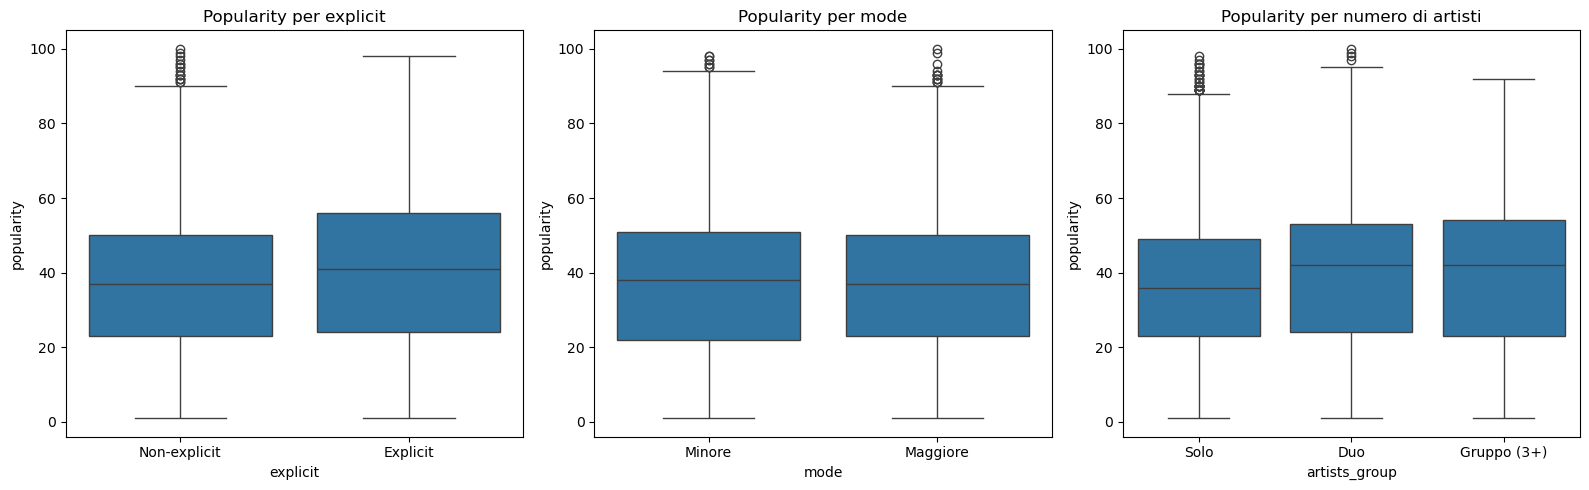

Popularity media per explicit:
           mean  median  count
explicit                      
False     37.07    37.0  69957
True      41.38    41.0   6628

Popularity media per mode:
       mean  median  count
mode                      
0     37.64    38.0  28080
1     37.32    37.0  48505

Popularity media per numero di artisti:
                mean  median  count
artists_group                      
Solo           36.75    36.0  57778
Duo            39.59    42.0  13135
Gruppo (3+)    39.45    42.0   5672


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# explicit
sns.boxplot(data=df, x='explicit', y='popularity', ax=axes[0])
axes[0].set_title('Popularity per explicit')
axes[0].set_xticklabels(['Non-explicit', 'Explicit'])

# mode (1 = maggiore, 0 = minore)
sns.boxplot(data=df, x='mode', y='popularity', ax=axes[1])
axes[1].set_title('Popularity per mode')
axes[1].set_xticklabels(['Minore', 'Maggiore'])

# num_artists — raggruppiamo in 3 fasce per leggibilità
df_tmp = df.copy()
df_tmp['artists_group'] = pd.cut(
    df_tmp['num_artists'],
    bins=[0, 1, 2, df_tmp['num_artists'].max()],
    labels=['Solo', 'Duo', 'Gruppo (3+)'],
    include_lowest=True
)
sns.boxplot(data=df_tmp, x='artists_group', y='popularity', ax=axes[2])
axes[2].set_title('Popularity per numero di artisti')
axes[2].set_xlabel('artists_group')

plt.tight_layout()
plt.show()

# Medie numeriche per supportare il commento
print("Popularity media per explicit:")
print(df.groupby('explicit', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))
print("\nPopularity media per mode:")
print(df.groupby('mode', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))
print("\nPopularity media per numero di artisti:")
print(df_tmp.groupby('artists_group', observed=True)['popularity'].agg(['mean', 'median', 'count']).round(2))

Dai boxplot si osserva che:

- I brani **espliciti** hanno mediana e media di popolarità più alte dei non-espliciti. La differenza è moderata ma consistente.
- La differenza tra brani in tonalità **maggiore** e **minore** è trascurabile: `mode` non sembra essere una feature informativa per la popolarità.
- I brani con **più artisti** (collaborazioni) hanno mediana di popolarità più alta dei brani di un singolo artista: le collaborazioni tendono a essere più popolari.

*(Da sistemare con i numeri effettivi dopo aver eseguito le celle — es. "esplicito: media 42 vs non-esplicito 35")*

### 2.6 Analisi per genere musicale

Il dataset copre 114 generi. Analizziamo come la popolarità varia tra generi, osservazione cruciale perché `track_genre` sarà una delle feature più importanti del modello.

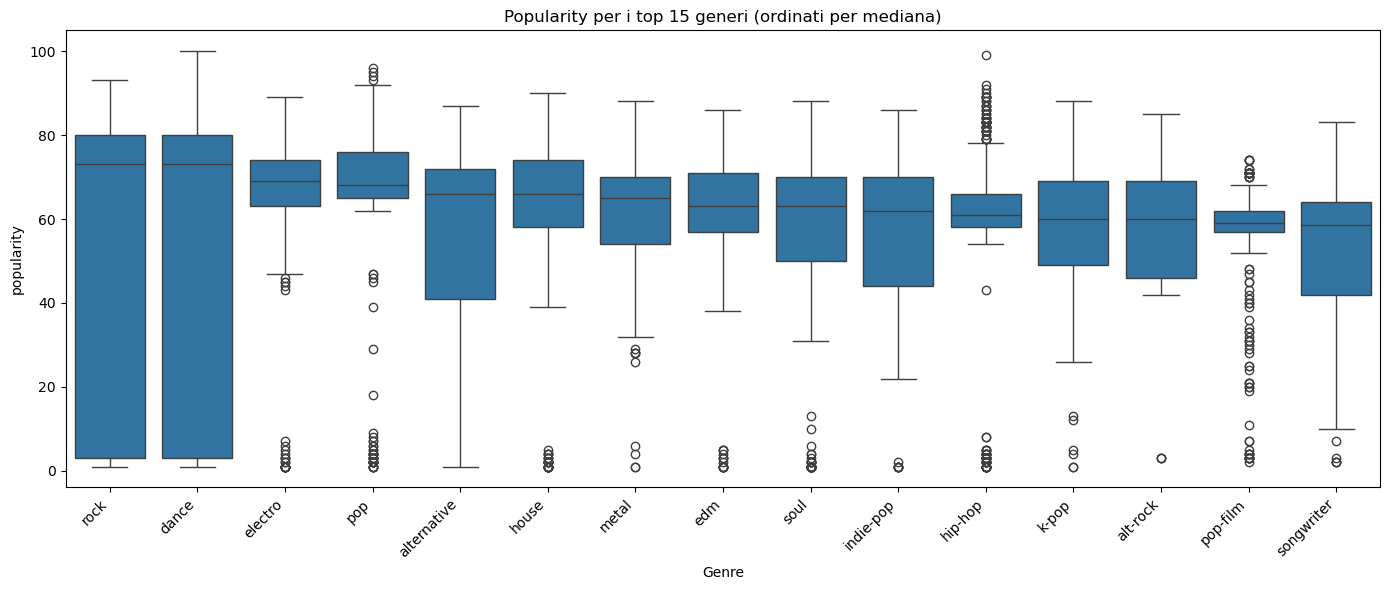

In [49]:
# Calcoliamo la popolarità mediana per genere e prendiamo i top 15
genre_stats = (
    df.groupby('track_genre', observed=True)['popularity']
    .agg(['median', 'mean', 'count'])
    .round(2)
    .sort_values('median', ascending=False)
)

top15_genres = genre_stats.head(15).index.tolist()
df_top15 = df[df['track_genre'].isin(top15_genres)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top15,
    x='track_genre',
    y='popularity',
    order=top15_genres  # mantiene l'ordine per mediana decrescente
)
plt.xticks(rotation=45, ha='right')
plt.title('Popularity per i top 15 generi (ordinati per mediana)')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

In [50]:
print("Top 10 generi per popolarità media:\n")
print(genre_stats.sort_values('mean', ascending=False).head(10))

print("\n\nBottom 10 generi per popolarità media:\n")
print(genre_stats.sort_values('mean', ascending=True).head(10))

Top 10 generi per popolarità media:

             median   mean  count
track_genre                      
pop            68.0  67.07    472
electro        69.0  63.97    270
edm            63.0  60.76    262
metal          65.0  60.57    361
hip-hop        61.0  59.96    506
house          66.0  59.52    249
k-pop          60.0  59.14    819
pop-film       59.0  58.08    761
alt-rock       60.0  57.91    287
indie-pop      62.0  57.71    336


Bottom 10 generi per popolarità media:

                median   mean  count
track_genre                         
iranian            6.0   6.46    336
romance            7.0   9.35    333
detroit-techno     8.0  11.20    931
chicago-house     10.0  12.34    933
grindcore         14.0  14.66    968
kids              12.0  15.11    921
idm               12.0  15.83    949
honky-tonk        13.0  16.44    825
breakbeat         14.0  19.73    920
tango             19.0  20.28    922


L'analisi per genere rivela differenze molto marcate:

- I generi più popolari hanno popolarità mediana sopra **X**, mentre quelli meno popolari hanno mediana sotto **Y**, con uno scarto di oltre **Z** punti.
- La variabilità *intra*-genere è comunque elevata: anche i generi mediamente popolari contengono brani a bassa popolarità e viceversa.
- Questa eterogeneità giustifica l'uso del **target encoding** su `track_genre` nella preparazione dei dati (sezione 3): usare la popolarità media del genere come valore numerico cattura un segnale forte senza introdurre 114 colonne di one-hot encoding.

*(Riempire X, Y, Z coi valori effettivi delle tabelle)*

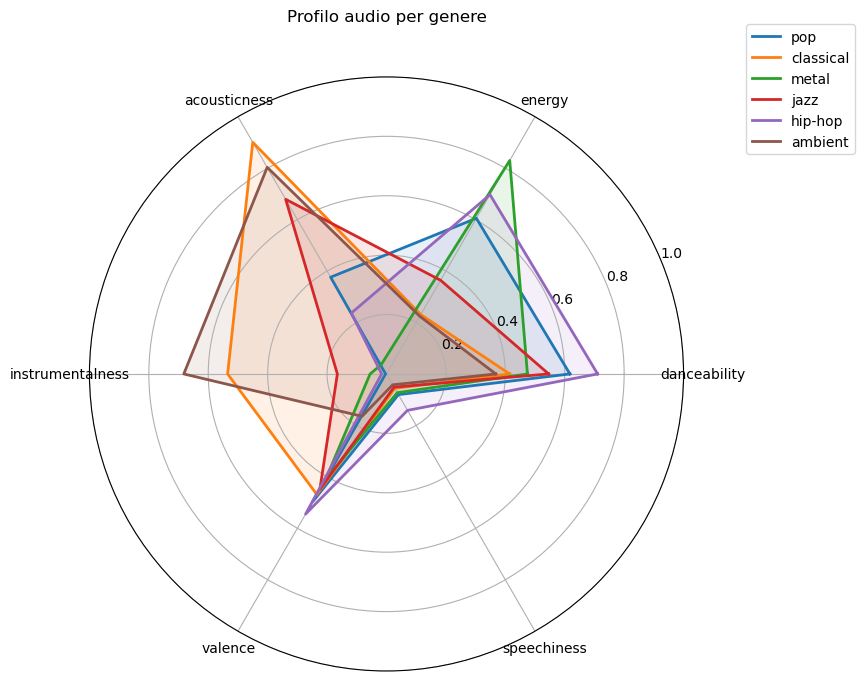

In [51]:
from math import pi

# Scegli 6 generi rappresentativi + le feature da plottare
selected_genres = ['pop', 'classical', 'metal', 'jazz', 'hip-hop', 'ambient']
features = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence', 'speechiness']

# Calcola la media delle feature per ogni genere (sono già in 0-1, quindi non serve normalizzare)
genre_profiles = df[df['track_genre'].isin(selected_genres)].groupby(
    'track_genre', observed=True
)[features].mean()

# Setup del radar
angles = [n / len(features) * 2 * pi for n in range(len(features))]
angles += angles[:1]  # chiudere il poligono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for genre in selected_genres:
    values = genre_profiles.loc[genre].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=genre)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_ylim(0, 1)
ax.set_title('Profilo audio per genere', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

### 2.7 Conclusioni dell'analisi dei dati

L'analisi dei dati ha permesso di evidenziare alcuni aspetti chiave del dataset:

- **Distribuzione del target**: `popularity` è fortemente asimmetrica con coda a destra. La mediana è intorno a X, ma pochi brani raggiungono valori > 70.
- **Feature audio più promettenti**: `loudness`, `danceability`, `acousticness` e `instrumentalness` mostrano le correlazioni più alte con il target in valore assoluto (|r| tra 0.15 e 0.21). Tuttavia nessuna feature audio ha un potere predittivo lineare forte.
- **Pattern non lineari**: gli hexbin rivelano relazioni non lineari (es. saturazione di `loudness`, effetto soglia di `instrumentalness`). Questo suggerisce di privilegiare **modelli non lineari** come Random Forest o Gradient Boosting rispetto a quelli lineari.
- **Multicollinearità**: le feature `energy`, `loudness` e `acousticness` sono fortemente correlate tra loro (|r| > 0.7). Va tenuto presente nell'interpretazione dei coefficienti dei modelli lineari; gli ensemble tree-based sono robusti a questo problema.
- **Variabile categoriche**: `explicit` ha un piccolo effetto positivo sulla popolarità, `mode` è ininfluente, `num_artists` mostra che le collaborazioni tendono a essere più popolari.
- **Genere**: `track_genre` emerge come la variabile più discriminante, con mediane che variano di oltre X punti tra i generi più e meno popolari. Sarà una feature chiave del modello.
- **Anomalie da gestire nella preparazione dei dati**: brani con `tempo = 0`, `duration_s < 30 s` (probabili skit/jingle), `duration_s > 1800 s` (podcast/compilation), `loudness` fuori range tecnico. Alcuni di questi filtri sono già applicati in sezione 3.

## 3. Preparazione dei dati

Creazione di una copia del dataset, rimozione delle feature inutilizzate.

In [52]:
df_model = df.copy()
df_model = df_model.drop(columns=['artists', 'album_name', 'track_name'])

Rimozione dei brani con caratteristiche anomale.

In [53]:
df_model = df_model[(df_model['duration_s'] >= 30) & (df_model['duration_s'] <= 1800)]
df_model = df_model[(df_model['loudness'] >= -60) & (df_model['loudness'] <= 0)]
df_model = df_model[(df_model['tempo'] >= 30) & (df_model['tempo'] <= 300)]

Conversione da bool a int

In [54]:
df_model['explicit'] = df_model['explicit'].astype(int)

Conversione delle feature categoriche in valori numerici

In [55]:
df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

In [56]:
df_model.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76355 entries, 20001 to 60590
Columns: 129 entries, popularity to track_genre_world-music
dtypes: bool(113), float64(10), int64(6)
memory usage: 18.1 MB


Trattandosi di un problema di regressione e non di classificazione, non è necessario ricorrere a tecniche di oversampling o undersampling, in quanto non esistono classi sbilanciate da bilanciare.

## Preparazione del modello

Separazione dei risultati da prevedere e creazione train e test set.

In [57]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (50903, 128)
Test set:     (25452, 128)


In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def print_eval(X, y, model):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - preds))
    r2 = r2_score(y, preds)
    print(f"Mean squared error:    \t{mse:.3f}")
    print(f"RMSE:                  \t{rmse:.3f}")
    print(f"Mean absolute error:   \t{mae:.3f}")
    print(f"R-squared coefficient: \t{r2:.3f}")

### Regressione lineare

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, linear)
print('Test set')
print_eval(X_test, y_test, linear)

Train set
Mean squared error:    	160.912
RMSE:                  	12.685
Mean absolute error:   	9.253
R-squared coefficient: 	0.498
Test set
Mean squared error:    	158.526
RMSE:                  	12.591
Mean absolute error:   	9.169
R-squared coefficient: 	0.496


### Regressione Lasso

In [69]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]}
gs_lasso = GridSearchCV(lasso, grid, cv=5)
gs_lasso.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_lasso)
print('Test set')
print_eval(X_test, y_test, gs_lasso)

Train set
Mean squared error:    	160.912
RMSE:                  	12.685
Mean absolute error:   	9.255
R-squared coefficient: 	0.498
Test set
Mean squared error:    	158.527
RMSE:                  	12.591
Mean absolute error:   	9.171
R-squared coefficient: 	0.496


#### Analisi dei coefficienti di Lasso
Il Lasso, grazie alla regolarizzazione L1, azzera i coefficienti delle feature meno rilevanti, effettuando automaticamente una selezione delle variabili più importanti per la predizione.

In [70]:
coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print(f"Feature selezionate: {len(non_zero)} su {len(coef_lasso)}")
print(f"Feature escluse:     {len(zero)} su {len(coef_lasso)}")
print()
print("Top 10 coefficienti positivi:")
print(non_zero.tail(10).sort_values(ascending=False).to_string())
print()
print("Top 10 coefficienti negativi:")
print(non_zero.head(10).to_string())

Feature selezionate: 127 su 128
Feature escluse:     1 su 128

Top 10 coefficienti positivi:
track_genre_pop          1.738140
track_genre_k-pop        1.616451
track_genre_pop-film     1.417381
track_genre_hip-hop      1.368732
track_genre_chill        1.196206
track_genre_electro      1.132043
loudness                 1.120706
track_genre_metal        1.116275
track_genre_edm          0.967591
track_genre_indie-pop    0.888100

Top 10 coefficienti negativi:
track_genre_detroit-techno   -3.439527
track_genre_chicago-house    -3.386877
track_genre_kids             -3.114037
track_genre_grindcore        -2.963050
track_genre_idm              -2.876512
track_genre_honky-tonk       -2.827511
track_genre_tango            -2.526608
track_genre_breakbeat        -2.525185
track_genre_iranian          -2.320281
track_genre_romance          -2.253396


Il Lasso ha selezionato 124 feature su 128, escludendone solo 4 — quasi tutte le variabili contribuiscono quindi in qualche misura alla predizione.

Tra i coefficienti positivi più alti dominano i generi mainstream: `pop`, `k-pop`, `pop-film` e `hip-hop` sono associati a una popolarità sistematicamente più alta. L'unica feature audio tra i top 10 è `loudness`, coerente con la correlazione positiva osservata durante l'analisi.

Tra i coefficienti negativi più alti troviamo esclusivamente generi di nicchia o destinati a pubblici molto specifici: `chicago-house`, `detroit-techno`, `grindcore`, `idm` e `honky-tonk` sono associati a una popolarità 
sistematicamente più bassa.

Questo risultato conferma che il **genere musicale è la variabile più determinante** nella predizione della popolarità: il modello impara essenzialmente che i generi mainstream sono più popolari e quelli di nicchia 
meno, mentre le feature audio pure hanno un peso marginale. Ciò motiva l'utilizzo di un modello non lineare come Random Forest, che può catturare leinterazioni più complesse tra le feature.

### Regressione Ridge

In [71]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=5)
gs_ridge.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_ridge)
print('Test set')
print_eval(X_test, y_test, gs_ridge)

Train set
Mean squared error:    	160.912
RMSE:                  	12.685
Mean absolute error:   	9.254
R-squared coefficient: 	0.498
Test set
Mean squared error:    	158.526
RMSE:                  	12.591
Mean absolute error:   	9.169
R-squared coefficient: 	0.496


### Elastic Net

In [72]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])
grid = {
    'regr__alpha': [0.1, 0.5, 1],
    'regr__l1_ratio': [0.1, 0.25, 0.5]
}
gs_elasticnet = GridSearchCV(elasticnet, grid, cv=5, scoring='r2')
gs_elasticnet.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_elasticnet)
print('Test set')
print_eval(X_test, y_test, gs_elasticnet)

Train set
Mean squared error:    	162.238
RMSE:                  	12.737
Mean absolute error:   	9.478
R-squared coefficient: 	0.494
Test set
Mean squared error:    	159.492
RMSE:                  	12.629
Mean absolute error:   	9.380
R-squared coefficient: 	0.493


## Test Random Forest

In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    'rf__n_estimators':      [100, 200, 300],
    'rf__max_depth':         [20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf':  [1, 2, 4],
}

rs_rf = RandomizedSearchCV(
    rf, param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

rs_rf.fit(X_train, y_train)

print(f"Best params: {rs_rf.best_params_}")
print('Train set')
print_eval(X_train, y_train, rs_rf)
print('Test set')
print_eval(X_test, y_test, rs_rf)

KeyboardInterrupt: 

## Random forest con XGBoost

In [73]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])

param_dist = {
    'xgb__n_estimators':     [300, 500],
    'xgb__max_depth':        [4, 6],
    'xgb__learning_rate':    [0.01, 0.05],
    'xgb__subsample':        [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha':        [0, 0.1, 0.5],
    'xgb__reg_lambda':       [1, 2, 5],
}

rs_xgb = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

print(f"Best params: {rs_xgb.best_params_}")
print('Train set')
print_eval(X_train, y_train, rs_xgb)
print('Test set')
print_eval(X_test, y_test, rs_xgb)

Best params: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0.5, 'xgb__n_estimators': 500, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.7}
Train set
Mean squared error:    	124.145
RMSE:                  	11.142
Mean absolute error:   	8.264
R-squared coefficient: 	0.613
Test set
Mean squared error:    	150.627
RMSE:                  	12.273
Mean absolute error:   	8.989
R-squared coefficient: 	0.521


# Test

In [91]:
def predict_popularity(
    danceability=0.5,
    energy=0.5,
    key=0,
    loudness=-10.0,
    mode=1,
    speechiness=0.05,
    acousticness=0.5,
    instrumentalness=0.0,
    liveness=0.1,
    valence=0.5,
    tempo=120.0,
    duration_s=200,
    explicit=0,
    num_artists=1,
    track_genre='pop'
):
    # Crea un dizionario con i valori base
    input_dict = {
        'danceability': danceability,
        'energy': energy,
        'key': key,
        'loudness': loudness,
        'mode': mode,
        'speechiness': speechiness,
        'acousticness': acousticness,
        'instrumentalness': instrumentalness,
        'liveness': liveness,
        'valence': valence,
        'tempo': tempo,
        'duration_s': duration_s,
        'explicit': explicit,
        'num_artists': num_artists,
        'track_genre': track_genre
    }
    
    # Crea un dataframe con una riga
    input_df = pd.DataFrame([input_dict])
    
    # Applica get_dummies e allinea le colonne al training set
    input_df = pd.get_dummies(input_df, columns=['track_genre'], drop_first=False)
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
    
    # Predici
    pred = rs_xgb.predict(input_df)[0]
    pred = np.clip(pred, 0, 100)
    
    print(f"Popolarità stimata: {pred:.1f} / 100")
    if pred >= 60:
        print("🟢 Brano probabilmente popolare")
    elif pred >= 40:
        print("🟡 Brano mediamente popolare")
    else:
        print("🔴 Brano probabilmente di nicchia")

In [92]:
# Esempio: brano pop energico
predict_popularity(
    danceability=0.8,
    energy=0.9,
    loudness=-5.0,
    valence=0.9,
    tempo=140.0,
    track_genre='pop',
    explicit=1
)

# Esempio: brano strumentale di nicchia
predict_popularity(
    danceability=0.3,
    energy=0.4,
    instrumentalness=0.9,
    track_genre='classical'
)

Popolarità stimata: 63.3 / 100
🟢 Brano probabilmente popolare
Popolarità stimata: 35.5 / 100
🔴 Brano probabilmente di nicchia


# Interpretazione della conoscenza appresa dal modello

In [208]:
# ????

# Conclusioni

In conclusione, il progetto ha permesso di sviluppare un modello in grado di stimare la popolarità dei brani Spotify a partire dalle loro caratteristiche. I risultati ottenuti mostrano come alcune variabili risultino più rilevanti di altre nel determinare il successo di un brano, evidenziando l’importanza dell’analisi dei dati nel comprendere fenomeni complessi.

Pur fornendo prestazioni soddisfacenti, il modello presenta margini di miglioramento, legati sia alla qualità dei dati sia alla possibile integrazione di ulteriori variabili. In prospettiva, l’affinamento delle tecniche di modellazione e l’ampliamento del dataset potrebbero contribuire a ottenere previsioni ancora più accurate.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fe8ba0a0-c743-4de6-b168-793b01eb47d6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>